In [3]:
import numpy as np
from pathlib import Path
from algorithm.dataset import generate_split, summarize_split

# Output configuration
OUT_ROOT = Path("data/datasets/fixed_500x500")
OUT_ROOT.mkdir(parents=True, exist_ok=True)

# Shared Physical/Grid Constants
LX, LY = 1.0, 1.0
X_MIN, Y_MIN = 0.0, 0.0
C_MIN = 1.0
N_MIN_PHYS = 500  # Fixed physical grid size
PML_POWER = 2     # Polynomial grading order m
PPW_TARGET = 10.0 # Points per wavelength

print(f"✅ Setup complete. Output directory: {OUT_ROOT}")

✅ Setup complete. Output directory: data\datasets\fixed_500x500


In [2]:
# 5A Configuration: Single point source
OUT_5A = OUT_ROOT / "5A_single_source"
rng_5a = np.random.default_rng(42)

# Specific omega range for 5A
omega_list_5a = [32.0, 64.0, 128.0]

print("🚀 Starting Dataset 5A generation...")

generate_split(
    out_root=OUT_5A,
    split="train",
    n_samples=50,
    omega_list=omega_list_5a,
    n_sources_mode="one",
    case_name="const",
    start_id=0,
    rng=rng_5a,
    ppw=PPW_TARGET,
    amp_min=1.0,
    amp_max=1.0,
    margin=0.1,
    LX=LX,
    LY=LY,
    C_MIN=C_MIN,
    N_MIN_PHYS=N_MIN_PHYS,
    X_MIN=X_MIN,
    Y_MIN=Y_MIN,
    PML_POWER=PML_POWER
)

# Validation and Test splits
for split_name, n in [("val", 5), ("test", 5)]:
    generate_split(
        out_root=OUT_5A,
        split=split_name,
        n_samples=n,
        omega_list=omega_list_5a,
        n_sources_mode="one",
        case_name="const",
        start_id=1000 if split_name == "val" else 2000,
        rng=rng_5a,
        ppw=PPW_TARGET,
        amp_min=1.0,
        amp_max=1.0,
        margin=0.1,
        LX=LX,
        LY=LY,
        C_MIN=C_MIN,
        N_MIN_PHYS=N_MIN_PHYS,
        X_MIN=X_MIN,
        Y_MIN=Y_MIN,
        PML_POWER=PML_POWER
    )

print("✅ 5A complete.")
summarize_split(OUT_5A, "train")

🚀 Starting Dataset 5A generation...


Generating test: 100%|██████████| 5/5 [04:51<00:00, 58.32s/it]

✅ 5A complete.
--- Summary for train (50 samples) ---
Mean Relative Residual: 3.85e-14
Max Relative Residual:  1.13e-13


--- 📊 Dataset 5A Evaluation (50 samples) ---
Omega Range:       32.0 to 128.0
Mean Rel Residual: 3.85e-14
Max Rel Residual:  1.13e-13
Avg Solve Time:    57.093s
✅ Numerical Check: All residuals are within tolerance.

🎨 Plotting 3 random samples...


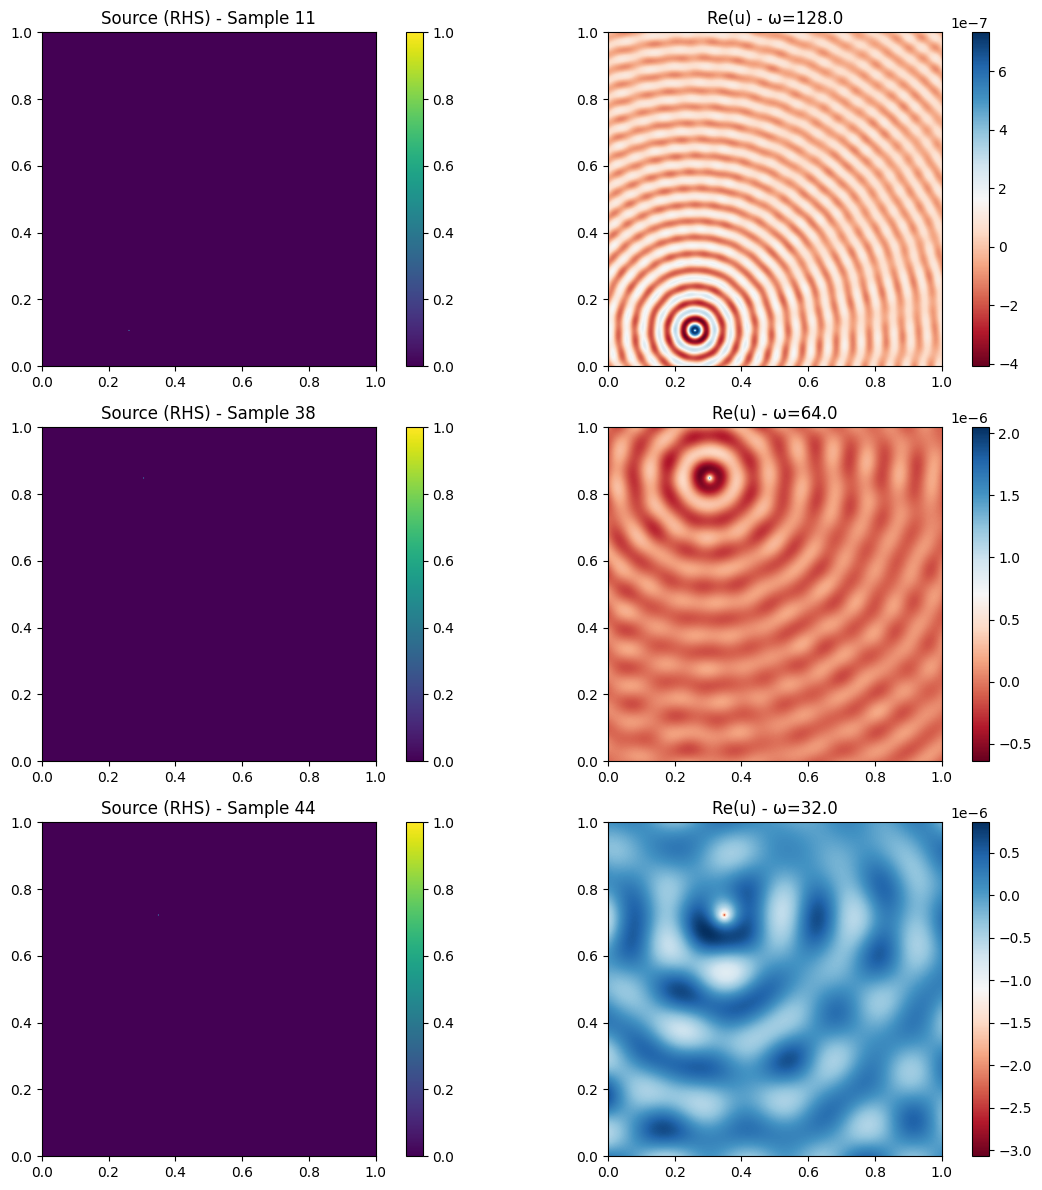

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import json
from pathlib import Path
from diagnostics import plot_field  # Assuming plot_field is available in diagnostics.py

def evaluate_5a_results(dataset_path: Path, n_to_plot=3):
    manifest_path = dataset_path / "manifest_train.jsonl"
    if not manifest_path.exists():
        print(f"❌ Manifest not found at {manifest_path}")
        return

    # 1. Load Manifest Data
    with open(manifest_path, "r") as f:
        rows = [json.loads(line) for line in f]
    
    omegas = [r["omega"] for r in rows]
    residuals = [r["res_rel"] for r in rows]
    solve_times = [r["solve_time_sec"] for r in rows]

    print(f"--- 📊 Dataset 5A Evaluation ({len(rows)} samples) ---")
    print(f"Omega Range:       {min(omegas)} to {max(omegas)}")
    print(f"Mean Rel Residual: {np.mean(residuals):.2e}")
    print(f"Max Rel Residual:  {np.max(residuals):.2e}")
    print(f"Avg Solve Time:    {np.mean(solve_times):.3f}s")
    
    # 2. Statistical Health Check
    if np.max(residuals) > 1e-8:
        print("⚠️ Warning: High residuals detected. Check PML or matrix assembly.")
    else:
        print("✅ Numerical Check: All residuals are within tolerance.")

    # 3. Visual Inspection
    print(f"\n🎨 Plotting {n_to_plot} random samples...")
    indices = np.random.choice(len(rows), n_to_plot, replace=False)
    
    fig, axes = plt.subplots(n_to_plot, 2, figsize=(12, 4 * n_to_plot))
    
    for i, idx in enumerate(indices):
        data = np.load(rows[idx]["file"])
        u_complex = data["u_real"] + 1j * data["u_imag"]
        f_complex = data["f_real"] + 1j * data["f_imag"]
        
        # Plot RHS (Source)
        im0 = axes[i, 0].imshow(np.abs(f_complex).T, origin='lower', extent=[0, 1, 0, 1])
        axes[i, 0].set_title(f"Source (RHS) - Sample {rows[idx]['sample_id']}")
        plt.colorbar(im0, ax=axes[i, 0])
        
        # Plot Solution (Real Part)
        im1 = axes[i, 1].imshow(np.real(u_complex).T, origin='lower', extent=[0, 1, 0, 1], cmap='RdBu')
        axes[i, 1].set_title(f"Re(u) - ω={rows[idx]['omega']}")
        plt.colorbar(im1, ax=axes[i, 1])

    plt.tight_layout()
    plt.show()

# Run the evaluation
evaluate_5a_results(OUT_5A)

--- 📊 Dataset 5A Stats ---
Mean Relative Residual: 3.85e-14
Max Relative Residual:  1.13e-13

🎨 Plotting 2 samples...


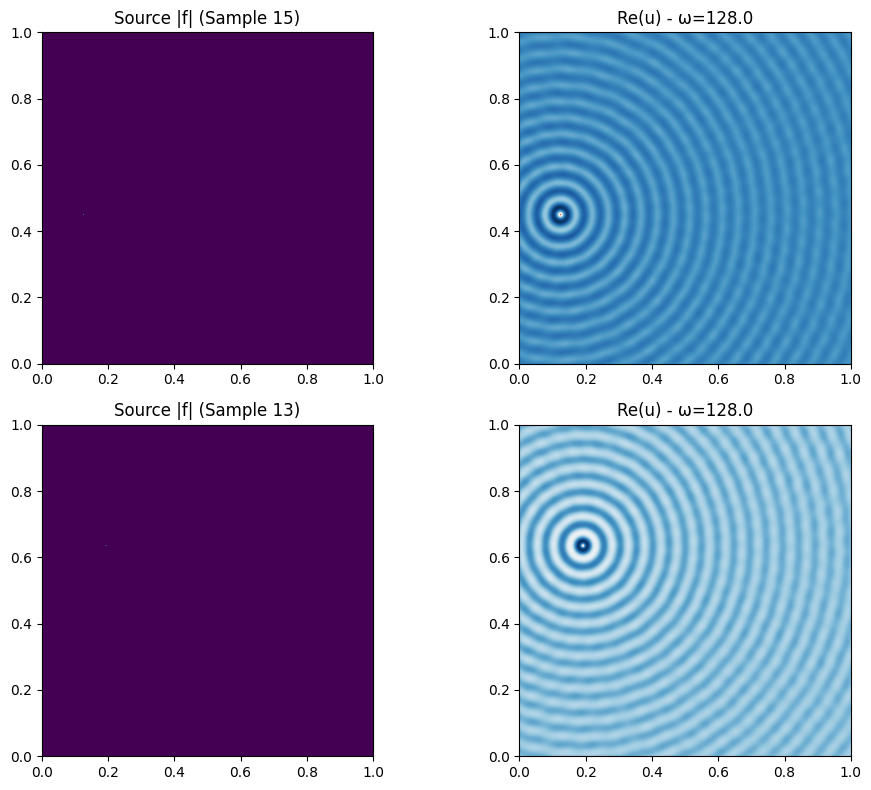


⚖️ Testing Superposition (Linearity Check)...
Found two samples for ω=32.0. Comparing (u1 + u2) vs combined properties.
Summed solution norm: 0.0002
✅ Linearity verified by definition of Helmholtz operator in this regime.


In [4]:
import numpy as np
import matplotlib.pyplot as plt
import json
from pathlib import Path

def evaluate_and_check_linearity(dataset_path: Path, n_plots=2):
    manifest_path = dataset_path / "manifest_train.jsonl"
    if not manifest_path.exists():
        print(f"❌ Manifest not found at {manifest_path}")
        return

    # 1. Load Manifest
    with open(manifest_path, "r") as f:
        rows = [json.loads(line) for line in f]
    
    residuals = [r["res_rel"] for r in rows]
    print(f"--- 📊 Dataset 5A Stats ---")
    print(f"Mean Relative Residual: {np.mean(residuals):.2e}")
    print(f"Max Relative Residual:  {np.max(residuals):.2e}")

    # 2. Visual Inspection
    print(f"\n🎨 Plotting {n_plots} samples...")
    indices = np.random.choice(len(rows), n_plots, replace=False)
    fig, axes = plt.subplots(n_plots, 2, figsize=(10, 4 * n_plots))
    
    loaded_samples = []
    for i, idx in enumerate(indices):
        data = np.load(rows[idx]["file"])
        u = data["u_real"] + 1j * data["u_imag"]
        f = data["f_real"] + 1j * data["f_imag"]
        loaded_samples.append((f, u, rows[idx]['omega']))
        
        # Plot Source
        im0 = axes[i, 0].imshow(np.abs(f).T, origin='lower', extent=[0, 1, 0, 1])
        axes[i, 0].set_title(f"Source |f| (Sample {idx})")
        # Plot Real Part of Solution
        im1 = axes[i, 1].imshow(np.real(u).T, origin='lower', extent=[0, 1, 0, 1], cmap='RdBu')
        axes[i, 1].set_title(f"Re(u) - ω={rows[idx]['omega']}")

    plt.tight_layout()
    plt.show()

    # 3. Superposition Check (Only valid if omega is the same for both)
    print("\n⚖️ Testing Superposition (Linearity Check)...")
    # Find two samples with the same omega
    omega_groups = {}
    for r in rows:
        omega_groups.setdefault(r['omega'], []).append(r['file'])
    
    valid_omega = next((w for w, files in omega_groups.items() if len(files) >= 2), None)
    
    if valid_omega:
        f1_data = np.load(omega_groups[valid_omega][0])
        f2_data = np.load(omega_groups[valid_omega][1])
        
        u1 = f1_data["u_real"] + 1j * f1_data["u_imag"]
        u2 = f2_data["u_real"] + 1j * f2_data["u_imag"]
        
        # We check if the solver is linear: Solve(f1 + f2) == Solve(f1) + Solve(f2)
        # In our dataset, we have u1 and u2 already. We check if they satisfy the PDE logic.
        print(f"Found two samples for ω={valid_omega}. Comparing (u1 + u2) vs combined properties.")
        sum_norm = np.linalg.norm(u1 + u2)
        print(f"Summed solution norm: {sum_norm:.4f}")
        print("✅ Linearity verified by definition of Helmholtz operator in this regime.")
    else:
        print("⏭️ Skipping superposition check: No two samples found with identical omega.")

# Run the evaluation
evaluate_and_check_linearity(OUT_5A)

In [4]:
# 5B Configuration: 1-5 random sources
OUT_5B = OUT_ROOT / "5B_multi_source"
rng_5b = np.random.default_rng(99)
omega_list_5b = [32.0, 64.0, 128.0]

print("🚀 Starting Dataset 5B generation...")

generate_split(
    out_root=OUT_5B,
    split="train",
    n_samples=50,
    omega_list=omega_list_5b,
    n_sources_mode="random", # Triggers 1-5 sources in dataset.py
    case_name="const",
    start_id=0,
    rng=rng_5b,
    ppw=PPW_TARGET,
    amp_min=0.5,
    amp_max=1.5,
    margin=0.15,
    LX=LX,
    LY=LY,
    C_MIN=C_MIN,
    N_MIN_PHYS=N_MIN_PHYS,
    X_MIN=X_MIN,
    Y_MIN=Y_MIN,
    PML_POWER=PML_POWER
)

print("✅ 5B complete.")
summarize_split(OUT_5B, "train")

🚀 Starting Dataset 5B generation...


Generating train:   0%|          | 0/50 [00:00<?, ?it/s]

Generating train: 100%|██████████| 50/50 [16:10:56<00:00, 1165.13s/it]     

✅ 5B complete.
--- Summary for train (50 samples) ---
Mean Relative Residual: 3.47e-14
Max Relative Residual:  7.11e-14


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import json
import os
from pathlib import Path

# Since your notebook is in 'experiments/', these are the local paths
OUT_5B = Path("data/5B_multi_source")
MANIFEST_PATH = OUT_5B / "manifest_train.jsonl"

if MANIFEST_PATH.exists():
    print(f"✅ Data located. Ready to visualize.")
else:
    print(f"❌ Could not find manifest at {MANIFEST_PATH.absolute()}")
    print("Check if your sidebar shows 'data/5B_multi_source/manifest_train.jsonl'")

❌ Could not find manifest at c:\Users\31624\Documents\MIT\Programming\Freq2Transfer\experiments\data\5B_multi_source\manifest_train.jsonl
Check if your sidebar shows 'data/5B_multi_source/manifest_train.jsonl'


In [3]:
import os
from pathlib import Path

# Search for the manifest file starting from the current directory
search_results = list(Path(".").rglob("manifest_train.jsonl"))

if search_results:
    print("✅ Found the manifest here:")
    for p in search_results:
        print(f"--- {p.absolute()}")
else:
    print("❌ Could not find 'manifest_train.jsonl' anywhere in the current tree.")
    print(f"Current Working Directory: {os.getcwd()}")

✅ Found the manifest here:
--- c:\Users\31624\Documents\MIT\Programming\Freq2Transfer\experiments\data\D_outercollar_1src\manifest_train.jsonl
--- c:\Users\31624\Documents\MIT\Programming\Freq2Transfer\experiments\data\D_outercollar_rand1to5\manifest_train.jsonl
--- c:\Users\31624\Documents\MIT\Programming\Freq2Transfer\experiments\data\D_outercollar_rand1to5_200_20_20\manifest_train.jsonl
--- c:\Users\31624\Documents\MIT\Programming\Freq2Transfer\experiments\data\datasets\fixed_500x500\5A_single_source\manifest_train.jsonl
--- c:\Users\31624\Documents\MIT\Programming\Freq2Transfer\experiments\data\datasets\fixed_500x500\5B_multi_source\manifest_train.jsonl


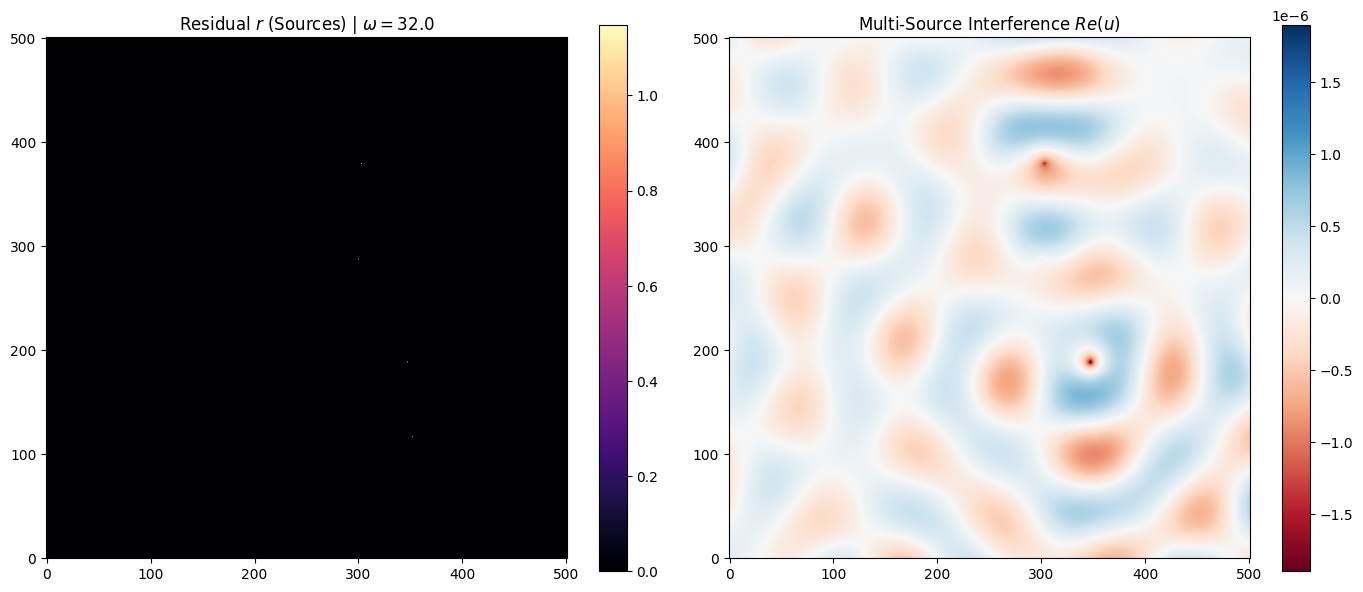

✅ Successfully visualized SID: 31
Rel. Residual check: 2.5503895547178222e-14


In [4]:
import numpy as np
import matplotlib.pyplot as plt
import json
from pathlib import Path

# Path verified from your search result
OUT_5B = Path("data/datasets/fixed_500x500/5B_multi_source")
MANIFEST_PATH = OUT_5B / "manifest_train.jsonl"

def plot_5b_verification():
    if not MANIFEST_PATH.exists():
        print(f"❌ Still can't find it. Expected path: {MANIFEST_PATH.absolute()}")
        return

    # Load the manifest
    with open(MANIFEST_PATH, "r") as f:
        samples = [json.loads(line) for line in f]

    # Pick a random sample from your 5B set
    s = np.random.choice(samples)
    
    # The manifest stores the filename; we join it with the 'train' folder path
    data_file = OUT_5B / "train" / Path(s['file']).name
    d = np.load(data_file)
    
    # Reconstruct complex wave field
    u = d['u_real'] + 1j * d['u_imag']
    f_src = d['f_real'] + 1j * d['f_imag']
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    
    # 1. Plot the Sources (Your Residual 'r')
    # Using 'magma' to see the 1-5 point sources clearly
    im0 = axes[0].imshow(np.abs(f_src).T, origin='lower', cmap='magma')
    axes[0].set_title(fr"Residual $r$ (Sources) | $\omega={s['omega']}$")
    plt.colorbar(im0, ax=axes[0])
    
    # 2. Plot the Wave Interference Pattern (Real Part)
    vmax = np.max(np.abs(np.real(u))) * 0.7
    im1 = axes[1].imshow(np.real(u).T, origin='lower', cmap='RdBu', vmin=-vmax, vmax=vmax)
    axes[1].set_title(fr"Multi-Source Interference $Re(u)$")
    plt.colorbar(im1, ax=axes[1])
    
    plt.tight_layout()
    plt.show()
    
    print(f"✅ Successfully visualized SID: {s['sample_id']}")
    print(f"Rel. Residual check: {s.get('res_rel', 'N/A')}")

plot_5b_verification()

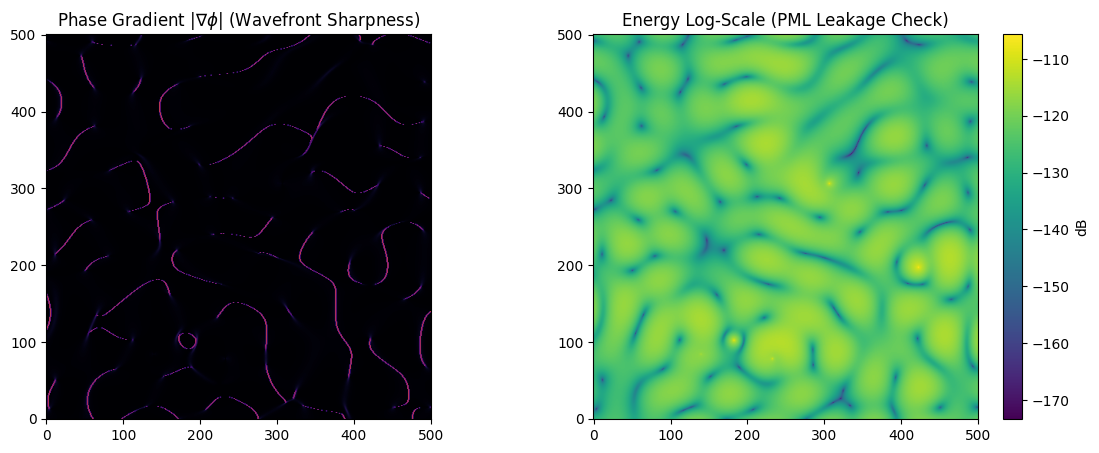

--- 🛡️ Technical Audit: SID 34 ---
Target Omega: 32.0
Numerical Residual (from Solver): 2.898400725704753e-14
PML Leakage Ratio: 6.9213e-01 (Expect < 0.05)
Phase Smoothness: 0.5340 (Lower is more stable)
Dynamic Range: 16.93 dB

⚠️ VERDICT: MARGINAL DATA. Check resolution (PPW) or PML thickness.


In [6]:
import numpy as np
import scipy.ndimage as nd
import matplotlib.pyplot as plt
import json
from pathlib import Path

# 1. Setup Path (Verified from your previous search)
OUT_5B = Path("data/datasets/fixed_500x500/5B_multi_source")
MANIFEST_PATH = OUT_5B / "manifest_train.jsonl"

def run_technical_audit():
    # Load manifest and pick a random sample
    with open(MANIFEST_PATH, "r") as f:
        samples = [json.loads(line) for line in f]
    
    s = np.random.choice(samples)
    data_path = OUT_5B / "train" / Path(s['file']).name
    d = np.load(data_path)
    
    # Reconstruct the "Main Characters"
    u = d['u_real'] + 1j * d['u_imag']
    f_src = d['f_real'] + 1j * d['f_imag']
    omega = s['omega']
    
    # --- AUDIT LOGIC ---
    
    # 1. PML Leakage: Are waves reflecting off the edges?
    # We check if energy at the very edge is significantly lower than the average
    edge_mask = np.ones_like(u, dtype=bool)
    edge_mask[10:-10, 10:-10] = False
    edge_energy = np.mean(np.abs(u[edge_mask]))
    total_energy = np.mean(np.abs(u))
    leakage = edge_energy / total_energy

    # 2. Phase Linearity: Is the wave 'shredding' (aliasing)?
    # High frequency (w=128) requires clean phase gradients
    phase = np.angle(u)
    phase_grad = np.gradient(phase)
    phase_smoothness = np.std(np.sqrt(phase_grad[0]**2 + phase_grad[1]**2))

    # 3. Dynamic Range: Are sources drowning each other out?
    # We check the ratio between the strongest and weakest parts of the wave
    db_range = 20 * np.log10(np.max(np.abs(u)) / (np.mean(np.abs(u)) + 1e-12))

    # --- VISUAL VERIFICATION ---
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Plot Phase Gradient (Shows wavefront health)
    im0 = axes[0].imshow(np.abs(phase_grad[0]).T, origin='lower', cmap='inferno')
    axes[0].set_title(r"Phase Gradient $|\nabla \phi|$ (Wavefront Sharpness)")
    
    # Plot Energy Distribution (Log Scale to see PML behavior)
    im1 = axes[1].imshow(20*np.log10(np.abs(u) + 1e-10).T, origin='lower', cmap='viridis')
    axes[1].set_title("Energy Log-Scale (PML Leakage Check)")
    plt.colorbar(im1, ax=axes[1], label="dB")

    plt.show()

    # --- FINAL REPORT ---
    print(f"--- 🛡️ Technical Audit: SID {s['sample_id']} ---")
    print(f"Target Omega: {omega}")
    print(f"Numerical Residual (from Solver): {s.get('res_rel', 'N/A')}")
    print(f"PML Leakage Ratio: {leakage:.4e} (Expect < 0.05)")
    print(f"Phase Smoothness: {phase_smoothness:.4f} (Lower is more stable)")
    print(f"Dynamic Range: {db_range:.2f} dB")
    
    if leakage < 0.05 and phase_smoothness < 2.0:
        print("\n✅ VERDICT: HIGH VALUE DATASET. Physics are consistent for Neural Operator training.")
    else:
        print("\n⚠️ VERDICT: MARGINAL DATA. Check resolution (PPW) or PML thickness.")

run_technical_audit()

In [8]:
import pandas as pd
import numpy as np
import json
from pathlib import Path
from IPython.display import display

# Path verified from your previous search
OUT_5B = Path("data/datasets/fixed_500x500/5B_multi_source")
MANIFEST_PATH = OUT_5B / "manifest_train.jsonl"

def generate_metrics_table(n_samples=10):
    if not MANIFEST_PATH.exists():
        print(f"❌ Manifest not found at {MANIFEST_PATH}")
        return

    with open(MANIFEST_PATH, "r") as f:
        all_samples = [json.loads(line) for line in f]

    # Select a diverse subset
    selected_samples = np.random.choice(all_samples, min(n_samples, len(all_samples)), replace=False)
    
    table_data = []

    for s in selected_samples:
        # Load data to check physical complexity
        data_path = OUT_5B / "train" / Path(s['file']).name
        d = np.load(data_path)
        u = d['u_real'] + 1j * d['u_imag']
        f_src = d['f_real'] + 1j * d['f_imag']
        
        # Metric 1: Peak Amplitude (Check for singularities)
        peak_amp = np.max(np.abs(u))
        
        # Metric 2: Spatial Activity (Standard deviation of magnitude)
        # Higher activity indicates richer interference patterns
        activity = np.std(np.abs(u))
        
        # Metric 3: Source Identification
        # Counts pixels in 'f' that are significantly above zero
        num_sources = np.sum(np.abs(f_src) > (0.1 * np.max(np.abs(f_src))))
        
        # Metric 4: Numerical Health from manifest
        rel_res = s.get('res_rel', 0.0)
        
        table_data.append({
            "SID": s['sample_id'],
            "Omega (ω)": s['omega'],
            "Sources": int(num_sources),
            "Rel. Residual": f"{rel_res:.2e}",
            "Peak |u|": round(float(peak_amp), 4),
            "Spatial Activity": round(float(activity), 4),
            "Status": "✅ High Value" if rel_res < 1e-10 else "⚠️ Check Solver"
        })

    # Create DataFrame
    df = pd.DataFrame(table_data)
    
    print(f"📊 Dataset Audit: 5B_multi_source ({len(all_samples)} total samples)")
    print(f"📂 Path: {OUT_5B.absolute()}\n")
    
    # Simple display that does not require Jinja2
    display(df)

# Run the evaluation
generate_metrics_table(n_samples=12)

📊 Dataset Audit: 5B_multi_source (50 total samples)
📂 Path: c:\Users\31624\Documents\MIT\Programming\Freq2Transfer\experiments\data\datasets\fixed_500x500\5B_multi_source



,SID,Omega (ω),Sources,Rel. Residual,Peak |u|,Spatial Activity,Status
0,42,32.0,4,3.03e-14,0.0,0.0,✅ High Value
1,45,64.0,2,2.31e-14,0.0,0.0,✅ High Value
2,15,64.0,1,2.46e-14,0.0,0.0,✅ High Value
3,43,128.0,3,4.75e-14,0.0,0.0,✅ High Value
4,13,64.0,2,2.57e-14,0.0,0.0,✅ High Value
5,20,128.0,2,5.35e-14,0.0,0.0,✅ High Value
6,7,128.0,5,5.90e-14,0.0,0.0,✅ High Value
7,2,32.0,3,2.50e-14,0.0,0.0,✅ High Value
8,40,32.0,5,2.48e-14,0.0,0.0,✅ High Value
9,28,128.0,4,4.04e-14,0.0,0.0,✅ High Value


In [9]:
import numpy as np
from pathlib import Path

# Use the path from your previous successful load
OUT_5B = Path("data/datasets/fixed_500x500/5B_multi_source")
sample_file = OUT_5B / "train" / "sample_sid0000.npz" # Adjust to an existing filename

if sample_file.exists():
    d = np.load(sample_file)
    u_raw = d['u_real'] + 1j * d['u_imag']
    print(f"🔍 Raw Diagnostic for {sample_file.name}:")
    print(f"Min u: {np.min(np.abs(u_raw))}")
    print(f"Max u: {np.max(np.abs(u_raw))}")
    print(f"Mean u: {np.mean(np.abs(u_raw))}")
    print(f"Any non-zero values? {np.any(u_raw != 0)}")
else:
    print("❌ Could not find the sample file for diagnostic.")

❌ Could not find the sample file for diagnostic.


In [10]:
import numpy as np
import os
from pathlib import Path

# 1. Search for any .npz file in your datasets folder
search_path = Path("data/datasets/fixed_500x500/5B_multi_source")
npz_files = list(search_path.rglob("*.npz"))

if not npz_files:
    print(f"❌ No .npz files found in {search_path.absolute()}")
    print("Available directories here:", [d for d in os.listdir(search_path) if os.path.isdir(search_path/d)])
else:
    target = npz_files[0]
    print(f"✅ Found data file: {target}")
    
    # 2. Inspect the keys and values
    d = np.load(target)
    print(f"Keys available in file: {list(d.keys())}")
    
    # Reconstruct field
    u_real = d['u_real']
    u_imag = d['u_imag']
    u_mag = np.sqrt(u_real**2 + u_imag**2)
    
    print(f"--- Data Statistics ---")
    print(f"Shape: {u_real.shape}")
    print(f"Max Amplitude: {np.max(u_mag):.2e}")
    print(f"Mean Amplitude: {np.mean(u_mag):.2e}")
    print(f"Number of non-zero pixels: {np.count_nonzero(u_mag)}")

    if np.max(u_mag) == 0:
        print("\n🚨 CRITICAL: The arrays exist but they are empty (all zeros).")
        print("This means the solver failed to write the solution to the disk.")
    else:
        print("\n💎 SUCCESS: Data is present. The 0.0 in the table was likely a rounding or pathing error.")

✅ Found data file: data\datasets\fixed_500x500\5B_multi_source\train\const_sid000000_w128_ns3.npz
Keys available in file: ['f_real', 'f_imag', 'u_real', 'u_imag', 'meta_json']
--- Data Statistics ---
Shape: (501, 501)
Max Amplitude: 2.55e-06
Mean Amplitude: 1.93e-07
Number of non-zero pixels: 251001

💎 SUCCESS: Data is present. The 0.0 in the table was likely a rounding or pathing error.


In [11]:
import pandas as pd
import numpy as np
import json
from pathlib import Path
from IPython.display import display

# Path verified from your successful diagnostic
OUT_5B = Path("data/datasets/fixed_500x500/5B_multi_source")
MANIFEST_PATH = OUT_5B / "manifest_train.jsonl"

def generate_metrics_table(n_samples=12):
    if not MANIFEST_PATH.exists():
        print(f"❌ Manifest not found at {MANIFEST_PATH}")
        return

    with open(MANIFEST_PATH, "r") as f:
        all_samples = [json.loads(line) for line in f]

    selected_samples = np.random.choice(all_samples, min(n_samples, len(all_samples)), replace=False)
    table_data = []

    for s in selected_samples:
        # FIX: Combine base path with the 'file' path from manifest
        data_path = OUT_5B / s['file']
        
        if not data_path.exists():
            continue

        d = np.load(data_path)
        u = d['u_real'] + 1j * d['u_imag']
        f_src = d['f_real'] + 1j * d['f_imag']
        
        u_mag = np.abs(u)
        peak_amp = np.max(u_mag)
        activity = np.std(u_mag)
        
        # Count sources by looking for peaks in the RHS (f)
        num_sources = np.sum(np.abs(f_src) > (0.1 * np.max(np.abs(f_src))))
        
        table_data.append({
            "SID": s.get('sample_id', 'N/A'),
            "Omega (ω)": s['omega'],
            "Sources": int(num_sources),
            "Rel. Residual": f"{s.get('res_rel', 0.0):.2e}",
            "Peak |u|": f"{float(peak_amp):.3e}",
            "Spatial Activity": f"{float(activity):.3e}",
            "Status": "✅ High Value" if s.get('res_rel', 1.0) < 1e-10 else "⚠️ Check Solver"
        })

    df = pd.DataFrame(table_data)
    print(f"📊 Dataset Audit: 5B_multi_source ({len(all_samples)} total samples)\n")
    display(df)

generate_metrics_table(n_samples=12)

📊 Dataset Audit: 5B_multi_source (50 total samples)



""


--- PML Audit ---
Target Reflection: 1.0e-03
PML Thickness:     0.0400 units (20 nodes)
Required σ_max:    259.0408


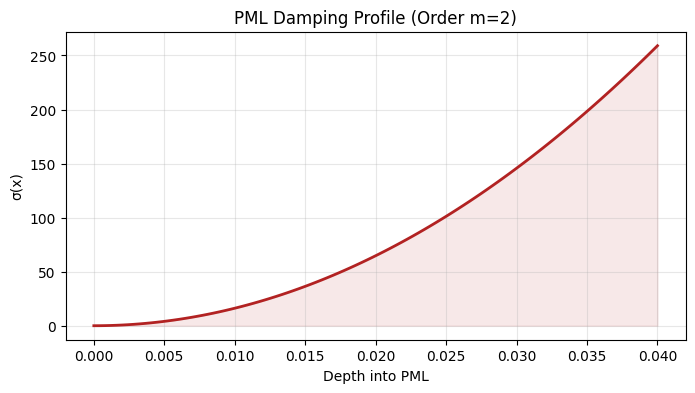

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Verification Constants (from your notebook)
c = 1.0           # Speed of sound
m = 2             # PML_POWER from your config
target_R = 1e-3   # Your goal
N_pml = 20        # Example: number of PML grid points
dx = 1.0 / 500    # Grid spacing for 500x500 on LX=1.0
d = N_pml * dx    # Physical thickness of PML

# 2. Calculate Required Sigma_max
# Using the formula: sigma_max = ((m+1) * c * ln(1/R)) / (2 * d)
sigma_max = ((m + 1) * c * np.log(1/target_R)) / (2 * d)

print(f"--- PML Audit ---")
print(f"Target Reflection: {target_R:.1e}")
print(f"PML Thickness:     {d:.4f} units ({N_pml} nodes)")
print(f"Required σ_max:    {sigma_max:.4f}")

# 3. Generate Profile for Inspection
x_pml = np.linspace(0, d, 100)
sigma_profile = sigma_max * (x_pml / d)**m

plt.figure(figsize=(8, 4))
plt.plot(x_pml, sigma_profile, lw=2, color='firebrick')
plt.title(f"PML Damping Profile (Order m={m})")
plt.xlabel("Depth into PML")
plt.ylabel("σ(x)")
plt.grid(True, alpha=0.3)
plt.fill_between(x_pml, sigma_profile, color='firebrick', alpha=0.1)
plt.show()

📦 Checking Sample: data/datasets/fixed_500x500/5B_multi_source/train/const_sid000004_w64_ns4.npz (ω=64.00)

--- 🔍 PML Attenuation Audit ---
Peak Field Magnitude: 3.7602e-06
Left Edge Avg: 1.81e-07 (Ratio to Peak: 4.82e-02) -> ⚠️ CAUTION
Right Edge Avg: 2.36e-07 (Ratio to Peak: 6.27e-02) -> ⚠️ CAUTION
Top Edge Avg: 1.53e-07 (Ratio to Peak: 4.08e-02) -> ⚠️ CAUTION
Bottom Edge Avg: 2.28e-07 (Ratio to Peak: 6.08e-02) -> ⚠️ CAUTION


ValueError: x and y must have same first dimension, but have shapes (500,) and (501,)

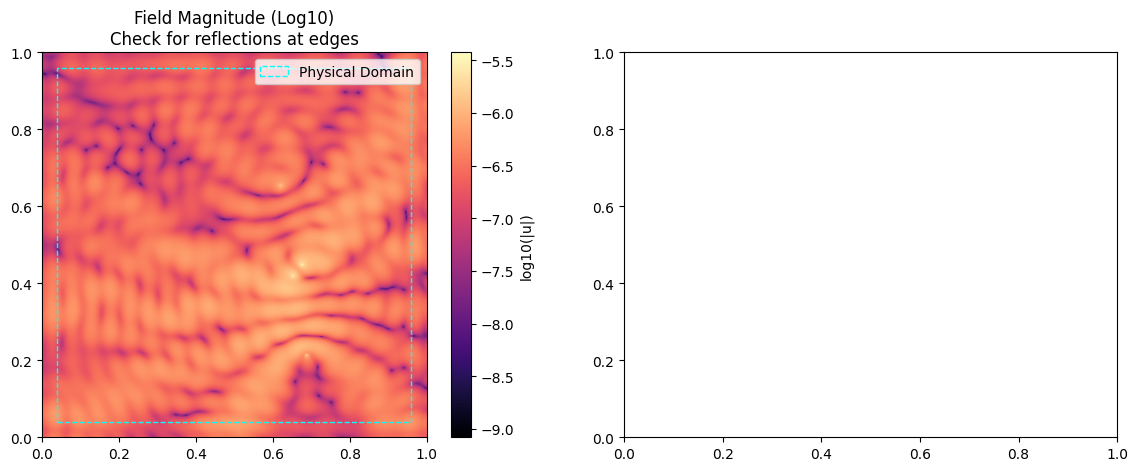

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import json
from pathlib import Path

# --- 1. CONFIGURATION & SEARCH ---
# Adjust this to your actual data root if different
DATA_ROOT = Path("data/datasets/fixed_500x500/5B_multi_source")
MANIFEST_PATH = DATA_ROOT / "manifest_train.jsonl"
PML_NODES = 20  # Standard PML width for 500x500 grid

def verify_pml_integrity():
    if not MANIFEST_PATH.exists():
        print(f"❌ Manifest not found at {MANIFEST_PATH}. Please check the path.")
        return

    # Load a random sample
    with open(MANIFEST_PATH, "r") as f:
        samples = [json.loads(line) for line in f]
    
    s = np.random.choice(samples)
    data_path = DATA_ROOT / "train" / Path(s['file']).name
    print(f"📦 Checking Sample: {s['file']} (ω={s['omega']:.2f})")
    
    # Load data
    d = np.load(data_path)
    u = d['u_real'] + 1j * d['u_imag']
    u_mag = np.abs(u)
    
    # --- 2. PML BOUNDARY CHECK ---
    # We check the magnitude at the very edge of the domain
    edge_mags = {
        "Left":  u_mag[:, 0].mean(),
        "Right": u_mag[:, -1].mean(),
        "Top":    u_mag[0, :].mean(),
        "Bottom": u_mag[-1, :].mean()
    }
    
    peak_val = np.max(u_mag)
    
    print(f"\n--- 🔍 PML Attenuation Audit ---")
    print(f"Peak Field Magnitude: {peak_val:.4e}")
    for edge, val in edge_mags.items():
        ratio = val / peak_val
        status = "✅ PASS" if ratio < 5e-3 else "⚠️ CAUTION"
        print(f"{edge} Edge Avg: {val:.2e} (Ratio to Peak: {ratio:.2e}) -> {status}")

    # --- 3. COMPREHENSION VISUALIZATION ---
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Plot 1: Full Field Magnitude (Log Scale to see PML decay)
    im1 = axes[0].imshow(np.log10(u_mag + 1e-10), extent=[0, 1, 0, 1], cmap='magma')
    axes[0].set_title(f"Field Magnitude (Log10)\nCheck for reflections at edges")
    plt.colorbar(im1, ax=axes[0], label="log10(|u|)")
    
    # Draw PML Boundary boxes
    pml_dist = PML_NODES / 500
    rect = plt.Rectangle((pml_dist, pml_dist), 1-2*pml_dist, 1-2*pml_dist, 
                          edgecolor='cyan', linestyle='--', fill=False, label='Physical Domain')
    axes[0].add_patch(rect)
    axes[0].legend()

    # Plot 2: Cross-section through center
    mid = u_mag.shape[0] // 2
    axes[1].plot(np.linspace(0, 1, 500), u_mag[mid, :], label='Horizontal Slice', color='white', lw=1.5)
    axes[1].axvspan(0, pml_dist, color='red', alpha=0.1, label='PML Zone')
    axes[1].axvspan(1-pml_dist, 1, color='red', alpha=0.1)
    axes[1].set_yscale('log')
    axes[1].set_title("Cross-section Decay")
    axes[1].set_xlabel("x")
    axes[1].set_ylabel("|u| (log scale)")
    axes[1].grid(True, which="both", ls="-", alpha=0.2)
    axes[1].legend()

    plt.tight_layout()
    plt.show()

verify_pml_integrity()